# **Đánh giá Phase 2 – Final TEST**

Notebook này chỉ thực hiện phân tích hậu kiểm (analysis-only) trên final TEST artifacts đã khóa. Không rerun experiment, model, Cross-Encoder, retrieval, calibration hay statistical test.


## **1. Mục tiêu và phạm vi phân tích**

Mục tiêu là kiểm tra, trực quan hóa và diễn giải kết quả TEST của PoolAdapt trên SciFact. PoolAdapt thực hiện query-specific adaptive reranking budget selection: chọn K(q) từ pre-reranking pool/query features, sau đó rerank RRF Top-K.


## **2. Dữ liệu và thiết lập thực nghiệm**

Dataset là SciFact; candidate pool N=100; TEST có 300 queries; target budgets là {10,20,30,50}; Full Rerank dùng K=100. Heuristic branch bị dừng do G2 FAIL nên không được đưa vào so sánh.


In [43]:
from pathlib import Path
import json
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
ARTIFACT_DIR = ROOT / "results" / "phase2" / "evaluation" / "final_gpu"
FIGURE_DIR = ROOT / "results" / "phase2" / "visualizations"
TARGETS, TOLERANCE = [10, 20, 30, 50], 0.05
METHODS = ["Fixed Prefix", "Random", "SAGE-SLO", "PACE-EF", "PoolAdapt", "Full Rerank"]
COLORS = {"PoolAdapt":"#1f77b4", "SAGE-SLO":"#ff7f0e", "Fixed Prefix":"#2ca02c",
          "PACE-EF":"#9467bd", "Random":"#7f7f7f", "Full Rerank":"#111111"}
plt.rcParams.update({"figure.dpi":120, "savefig.dpi":300, "font.size":10,
                     "axes.spines.top":False, "axes.spines.right":False})

def resolve_column(frame, candidates):
    """Tìm cột theo tên gốc hoặc tên đã chuẩn hoá; không sửa dữ liệu nguồn."""
    exact = {str(c).lower(): c for c in frame.columns}
    for candidate in candidates:
        if candidate.lower() in exact:
            return exact[candidate.lower()]
    normalize = lambda value: "".join(ch.lower() for ch in str(value) if ch.isalnum())
    normalized = {normalize(c): c for c in frame.columns}
    return next((normalized[normalize(x)] for x in candidates if normalize(x) in normalized), None)

def save_and_show(fig, filename):
    """Lưu và hiển thị cùng một figure; chỉ ghi đè các figure FINAL TEST 11–22."""
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path

if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy thư mục final: {ARTIFACT_DIR}")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("Thư mục final TEST:", ARTIFACT_DIR)


Thư mục final TEST: d:\Seminar KHDL\pooladapt\results\phase2\evaluation\final_gpu


## **3. Đọc và kiểm tra Final TEST Artifacts**

### 3.1. Kiểm tra file đầu vào

Resolved final artifact path: `results/phase2/evaluation/final_gpu/`. Final artifacts chính thức được đọc từ đường dẫn này; file optional thiếu sẽ được báo cáo, không tạo dữ liệu thay thế.


In [44]:
available = {path.name: path for path in ARTIFACT_DIR.iterdir()}

# budget_calibration.csv nằm ở parent directory của final_gpu
if "budget_calibration.csv" not in available:
    parent_calibration = ARTIFACT_DIR.parent / "budget_calibration.csv"
    if parent_calibration.exists():
        available["budget_calibration.csv"] = parent_calibration
        print(f"budget_calibration.csv: loaded from parent → {parent_calibration}")

print("Artifacts hiện có:", ", ".join(sorted(available)))

tables = {}

for name in [
    "budget_calibration.csv",
    "comparative_results.csv",
    "quality_cost_latency.csv",
    "random_seed_results.csv",
    "test_query_metrics.csv",
    "statistical_analysis.csv",
]:
    if name in available:
        tables[name] = pd.read_csv(available[name])
        print(
            f"{name}: "
            f"{tables[name].shape[0]:,} dòng × "
            f"{tables[name].shape[1]} cột"
        )
    else:
        print(f"{name}: không có")

summary = (
    json.loads(
        available["phase2_summary.json"].read_text(encoding="utf-8")
    )
    if "phase2_summary.json" in available
    else {}
)

manifest = (
    json.loads(
        available["execution_manifest.json"].read_text(encoding="utf-8")
    )
    if "execution_manifest.json" in available
    else {}
)

comp = tables.get(
    "comparative_results.csv",
    tables.get("quality_cost_latency.csv"),
)

if comp is None:
    raise ValueError(
        "Không có comparative_results.csv hoặc quality_cost_latency.csv."
    )

qm = tables.get("test_query_metrics.csv")
random_seed = tables.get("random_seed_results.csv")
stats = tables.get("statistical_analysis.csv")

mcol = resolve_column(comp, ["method"])
tcol = resolve_column(comp, ["target_budget", "budget"])
actual_col = resolve_column(
    comp,
    ["actual_average_budget", "avg_reranked_pairs"],
)

if not mcol or not tcol:
    raise ValueError(
        "Artifact tổng hợp thiếu cột method hoặc target budget."
    )

budget_calibration.csv: loaded from parent → d:\Seminar KHDL\pooladapt\results\phase2\evaluation\budget_calibration.csv
Artifacts hiện có: budget_calibration.csv, comparative_results.csv, execution_manifest.json, phase2_summary.json, quality_cost_latency.csv, random_seed_results.csv, run.log, statistical_analysis.csv, test_predictions.jsonl, test_query_metrics.csv
budget_calibration.csv: 21 dòng × 10 cột
comparative_results.csv: 21 dòng × 21 cột
quality_cost_latency.csv: 21 dòng × 21 cột
random_seed_results.csv: 20 dòng × 21 cột
test_query_metrics.csv: 11,100 dòng × 9 cột
statistical_analysis.csv: 99 dòng × 17 cột


### 3.2. Kiểm tra số lượng TEST queries

### 3.3. Kiểm tra candidate pool

### 3.4. Kiểm tra trạng thái locked / calibration

Bảng audit bên dưới chỉ báo cáo quan sát từ artifacts; không sửa artifact.


In [45]:
audit_rows = [
    ("Thư mục final TEST", str(ARTIFACT_DIR), "ĐẠT"),
    ("Số TEST queries (metadata)", summary.get("test_query_count", "không ghi nhận"),
     "ĐẠT" if summary.get("test_query_count") == 300 else "CẦN KIỂM TRA"),
    ("Candidate pool N (metadata)", summary.get("candidate_pool_size", "không ghi nhận"),
     "ĐẠT" if summary.get("candidate_pool_size") == 100 else "CẦN KIỂM TRA"),
    ("Target budgets (metadata)", summary.get("target_budgets", "không ghi nhận"),
     "ĐẠT" if set(summary.get("target_budgets", [])) == set(TARGETS) else "CẦN KIỂM TRA"),
]
for key, expected in [("locked", True), ("test_used_for_calibration", False)]:
    value = summary.get(key, "không ghi nhận")
    audit_rows.append((key, value, "ĐẠT" if value == expected else ("KHÔNG CÓ" if key not in summary else "CẦN KIỂM TRA")))
for metric in ["nDCG@10", "Recall@10", "MRR@10", "avg_reranked_pairs", "compression_ratio",
               "mean_reranking_latency", "p50_reranking_latency", "p95_reranking_latency"]:
    audit_rows.append((f"Cột tổng hợp: {metric}", "có" if metric in comp else "thiếu",
                       "ĐẠT" if metric in comp else "CẦN KIỂM TRA"))
if qm is not None:
    qid, qmethod = resolve_column(qm, ["query_id", "qid"]), resolve_column(qm, ["method"])
    qtarget, qseed = resolve_column(qm, ["target_budget", "budget"]), resolve_column(qm, ["seed"])
    groups = [item for item in [qmethod, qtarget, qseed] if item]
    if qid and groups:
        duplicates = int(qm.duplicated(groups + [qid]).sum())
        coverage = qm.groupby(groups, dropna=False)[qid].nunique()
        audit_rows += [("Query ID trùng trong cùng run", duplicates, "ĐẠT" if duplicates == 0 else "CẦN KIỂM TRA"),
                       ("Phủ TEST query theo run", f"{coverage.min()}–{coverage.max()}",
                        "ĐẠT" if coverage.min() == coverage.max() == 300 else "CẦN KIỂM TRA")]
observed_methods = set(comp[mcol].dropna())
audit_rows.append(("Các method final", ", ".join(sorted(observed_methods)),
                   "ĐẠT" if set(METHODS).issubset(observed_methods) else "CẦN KIỂM TRA"))
full_rows = comp[comp[mcol].eq("Full Rerank")]
full_k_ok = not full_rows.empty and pd.to_numeric(full_rows[tcol], errors="coerce").eq(100).any()
audit_rows.append(("Full Rerank reference K=100", int(len(full_rows)), "ĐẠT" if full_k_ok else "CẦN KIỂM TRA"))
if actual_col and "compression_ratio" in comp.columns:
    expected_compression = 1 - pd.to_numeric(comp[actual_col], errors="coerce") / 100
    compression_mismatch = int((comp["compression_ratio"] - expected_compression).abs().gt(0.01).sum())
    audit_rows.append(("Compression consistency |recorded - (1-pairs/100)| > 0.01", compression_mismatch,
                       "ĐẠT" if compression_mismatch == 0 else "CẦN KIỂM TRA"))
display(pd.DataFrame(audit_rows, columns=["Kiểm tra", "Quan sát", "Trạng thái"]))


,Kiểm tra,Quan sát,Trạng thái
0,Thư mục final TEST,d:\Seminar KHDL\pooladapt\results\phase2\evalu...,ĐẠT
1,Số TEST queries (metadata),300,ĐẠT
2,Candidate pool N (metadata),100,ĐẠT
3,Target budgets (metadata),"[10, 20, 30, 50]",ĐẠT
4,locked,True,ĐẠT
5,test_used_for_calibration,False,ĐẠT
6,Cột tổng hợp: nDCG@10,có,ĐẠT
7,Cột tổng hợp: Recall@10,có,ĐẠT
8,Cột tổng hợp: MRR@10,có,ĐẠT
9,Cột tổng hợp: avg_reranked_pairs,có,ĐẠT


## **4. Kiểm tra Budget Calibration**

### 4.1. Target budget

### 4.2. Actual average budget

### 4.3. Kiểm tra tolerance ±5%

Phân tích matched-budget chính sử dụng trực tiếp cột `comparative_results.matched_budget`, là source of truth do artifact tổng hợp tạo ra. Notebook chỉ recompute quy tắc ±5% như một audit check; nếu khác artifact thì dừng với lỗi. `budget_calibration.csv` chỉ được đọc khi có để hiển thị cấu hình calibration đã khóa, không recalibrate hoặc thay đổi λ.


In [46]:
cal = tables.get("budget_calibration.csv")
if cal is not None:
    cal = cal.copy()
    cm, ct = resolve_column(cal, ["method"]), resolve_column(cal, ["target_budget", "budget"])
    ca, cs = resolve_column(cal, ["actual_average_budget", "avg_reranked_pairs"]), resolve_column(cal, ["calibration_status", "status"])
    if cm and ct and ca:
        calibration_audit = cal[cal[ct].isin(TARGETS)].copy()
        calibration_audit["Sai lệch tuyệt đối"] = (pd.to_numeric(calibration_audit[ca], errors="coerce") - calibration_audit[ct]).abs()
        calibration_audit["Sai lệch tương đối"] = calibration_audit["Sai lệch tuyệt đối"] / calibration_audit[ct]
        calibration_audit["Khớp ±5%"] = calibration_audit["Sai lệch tương đối"].le(TOLERANCE)
        calibration_audit["Trạng thái artifact"] = calibration_audit[cs].fillna("không ghi nhận") if cs else "không ghi nhận"
        calibration_view = calibration_audit[[cm, ct, ca, "Sai lệch tuyệt đối", "Sai lệch tương đối", "Khớp ±5%", "Trạng thái artifact"]].sort_values([cm, ct])
        calibration_view.columns = ["Method", "Target budget", "Actual average budget", "Sai lệch tuyệt đối", "Sai lệch tương đối", "Khớp ±5%", "Trạng thái artifact"]
        display(calibration_view.style.format({"Actual average budget":"{:.3f}", "Sai lệch tuyệt đối":"{:.3f}", "Sai lệch tương đối":"{:.1%}"}))
    else:
        calibration_audit, calibration_view = pd.DataFrame(), pd.DataFrame()
        print("Skip calibration configuration display: thiếu cột cần thiết.")
else:
    calibration_audit, calibration_view = pd.DataFrame(), pd.DataFrame()
    print("budget_calibration.csv không có trong final artifact; không hiển thị cấu hình calibration.")

artifact_matched_col = resolve_column(comp, ["matched_budget"])
if artifact_matched_col is None:
    raise ValueError("comparative_results.csv thiếu cột matched_budget (source of truth).")
artifact_matched = comp[artifact_matched_col]
if artifact_matched.dtype == object:
    artifact_matched = artifact_matched.astype(str).str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False})
if artifact_matched.isna().any():
    raise ValueError("Cột matched_budget chứa giá trị không hợp lệ.")
if actual_col:
    recomputed_matched_budget = ((pd.to_numeric(comp[actual_col], errors="coerce") - pd.to_numeric(comp[tcol], errors="coerce")).abs() / pd.to_numeric(comp[tcol], errors="coerce")).le(TOLERANCE)
    if not recomputed_matched_budget.eq(artifact_matched.astype(bool)).all():
        raise ValueError("Audit mismatch: recomputed ±5% không khớp comparative_results.matched_budget.")
matched = comp[artifact_matched.astype(bool) & comp[mcol].isin(METHODS)].copy()
full = comp[comp[mcol].eq("Full Rerank")].copy()
print(f"Có {len(matched)} dòng matched-budget theo artifact; {len(full)} dòng Full Rerank reference.")


,Method,Target budget,Actual average budget,Sai lệch tuyệt đối,Sai lệch tương đối,Khớp ±5%,Trạng thái artifact
8,Fixed Prefix,10,10.000,0.000,0.0%,True,NOT_REQUIRED
9,Fixed Prefix,20,20.000,0.000,0.0%,True,NOT_REQUIRED
10,Fixed Prefix,30,30.000,0.000,0.0%,True,NOT_REQUIRED
11,Fixed Prefix,50,50.000,0.000,0.0%,True,NOT_REQUIRED
12,PACE-EF,10,10.000,0.000,0.0%,True,NOT_REQUIRED
13,PACE-EF,20,20.000,0.000,0.0%,True,NOT_REQUIRED
14,PACE-EF,30,30.000,0.000,0.0%,True,NOT_REQUIRED
15,PACE-EF,50,50.000,0.000,0.0%,True,NOT_REQUIRED
0,PoolAdapt,10,10.000,0.000,0.0%,True,SUCCESS
1,PoolAdapt,20,20.000,0.000,0.0%,True,SUCCESS


Có 17 dòng matched-budget theo artifact; 1 dòng Full Rerank reference.


## **5. Phân tích Retrieval Quality**

Mục tiêu là so sánh nDCG@10, Recall@10 và MRR@10 giữa các phương pháp tại các budget thực sự matched. Full Rerank là reference động từ artifact.


In [47]:
wanted = [mcol, tcol, actual_col, "nDCG@10", "Recall@10", "MRR@10", "avg_reranked_pairs",
          "compression_ratio", "mean_reranking_latency"]
wanted = [column for column in wanted if column and column in comp.columns]
display(comp[comp[mcol].isin(METHODS)][wanted].sort_values([mcol, tcol]))


,method,target_budget,actual_average_budget,nDCG@10,Recall@10,MRR@10,avg_reranked_pairs,compression_ratio,mean_reranking_latency
8,Fixed Prefix,10,10.000000,0.674001,0.805889,0.637868,10.000000,0.900000,0.055474
9,Fixed Prefix,20,20.000000,0.671582,0.812944,0.634808,20.000000,0.800000,0.113311
10,Fixed Prefix,30,30.000000,0.668039,0.813611,0.629757,30.000000,0.700000,0.175320
11,Fixed Prefix,50,50.000000,0.679532,0.828889,0.639118,50.000000,0.500000,0.254039
16,Full Rerank,100,100.000000,0.672783,0.808889,0.636008,100.000000,0.000000,0.461770
12,PACE-EF,10,10.000000,0.670805,0.789389,0.641017,10.000000,0.900000,0.055507
13,PACE-EF,20,20.000000,0.673050,0.817944,0.635586,20.000000,0.800000,0.113152
14,PACE-EF,30,30.000000,0.671372,0.816944,0.633090,30.000000,0.700000,0.175365
15,PACE-EF,50,50.000000,0.679968,0.828889,0.639673,50.000000,0.500000,0.253985
0,PoolAdapt,10,10.266667,0.674848,0.808222,0.637868,10.266667,0.897333,0.057241


In [48]:
def plot_quality(metric, filename, title):
    if metric not in comp.columns:
        print(f"Skip {filename}: thiếu {metric}."); return
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    for method in METHODS[:-1]:
        subset = matched[matched[mcol].eq(method)].sort_values(actual_col)
        if not subset.empty:
            ax.plot(subset[actual_col], subset[metric], marker="o", linewidth=2, label=method, color=COLORS[method])
    if not full.empty and full[metric].notna().any():
        ax.axhline(full[metric].dropna().iloc[0], color=COLORS["Full Rerank"], linestyle="--", label="Full Rerank K=100 (reference)")
    ax.set(title=title, xlabel="Số candidate rerank trung bình / query", ylabel=metric)
    ax.legend(frameon=False, ncol=2)
    save_and_show(fig, filename)


### 5.1. nDCG@10


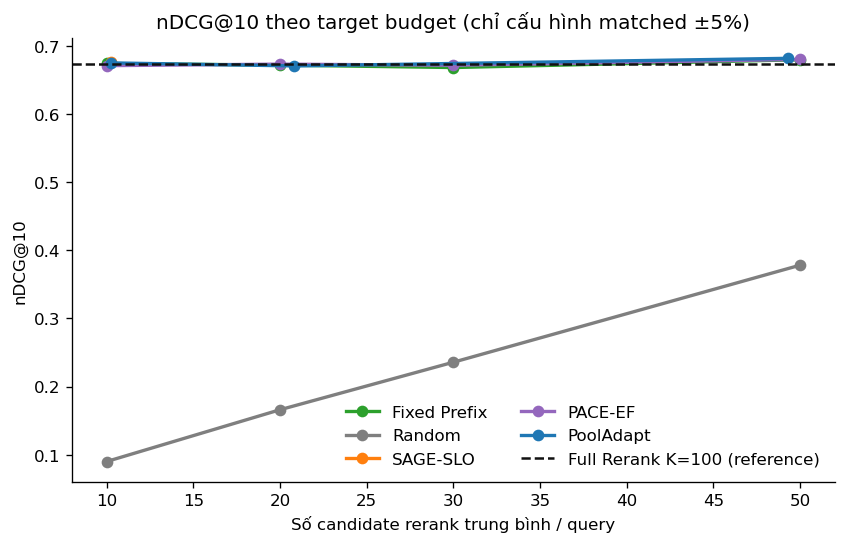

In [49]:
plot_quality("nDCG@10", "11_test_ndcg_at_10_vs_budget.png", "nDCG@10 theo target budget (chỉ cấu hình matched ±5%)")


### 5.2. Recall@10


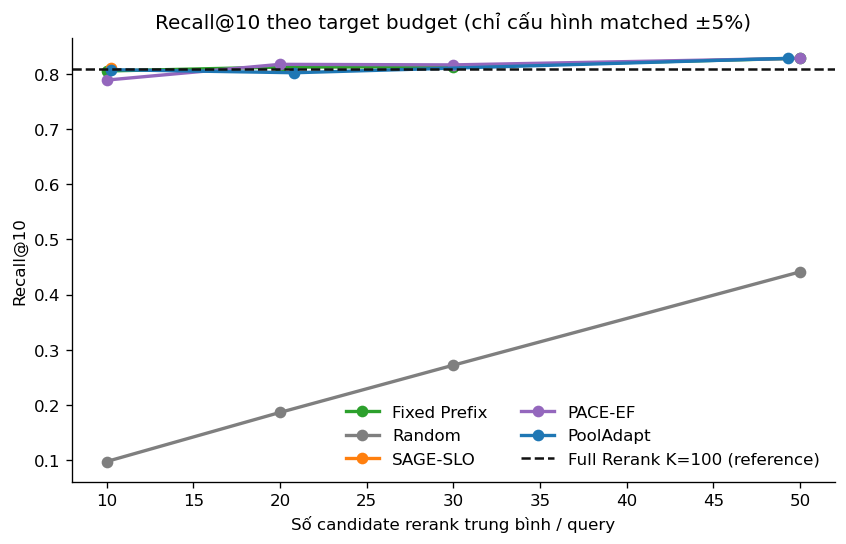

In [50]:
plot_quality("Recall@10", "12_test_recall_at_10_vs_budget.png", "Recall@10 theo target budget (chỉ cấu hình matched ±5%)")


### 5.3. MRR@10


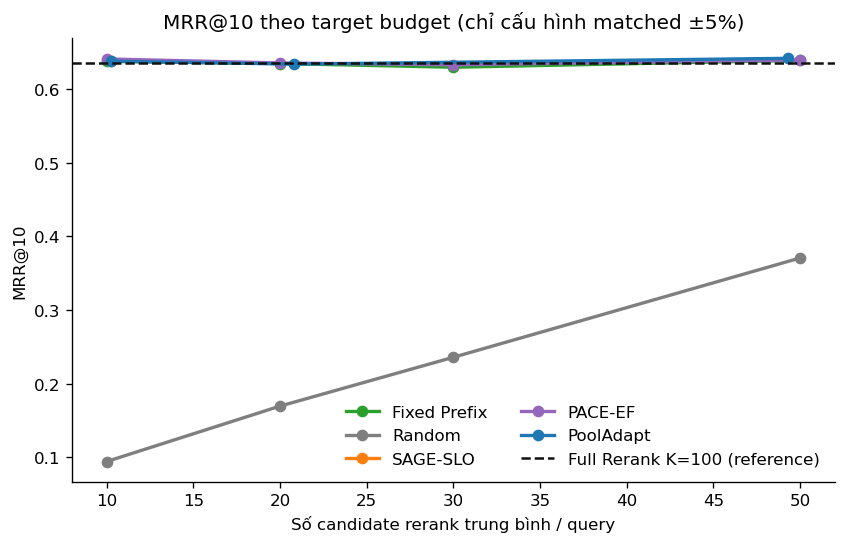

In [51]:
plot_quality("MRR@10", "13_test_mrr_at_10_vs_budget.png", "MRR@10 theo target budget (chỉ cấu hình matched ±5%)")


## **6. Phân tích Inference Cost**

### 6.1. Average reranked pairs/query

### 6.2. Compression ratio

Các giá trị compression ratio được dùng nguyên trạng từ artifact.


In [52]:
def plot_bars(value, filename, title, ylabel, include_full=True):
    subset = matched[matched[mcol].isin(METHODS[:-1])].copy()
    if include_full:
        subset = pd.concat([subset, full], ignore_index=True)
    if subset.empty or value not in subset.columns:
        print(f"Skip {filename}: thiếu dữ liệu {value}."); return
    labels = [f"{row[mcol]}\nB={int(row[tcol])}" if pd.notna(row[tcol]) else row[mcol] for _, row in subset.iterrows()]
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.bar(range(len(subset)), subset[value], color=[COLORS.get(x, "#333333") for x in subset[mcol]])
    ax.set(title=title, ylabel=ylabel, xticks=range(len(subset)), xticklabels=labels)
    ax.tick_params(axis="x", rotation=45)
    save_and_show(fig, filename)


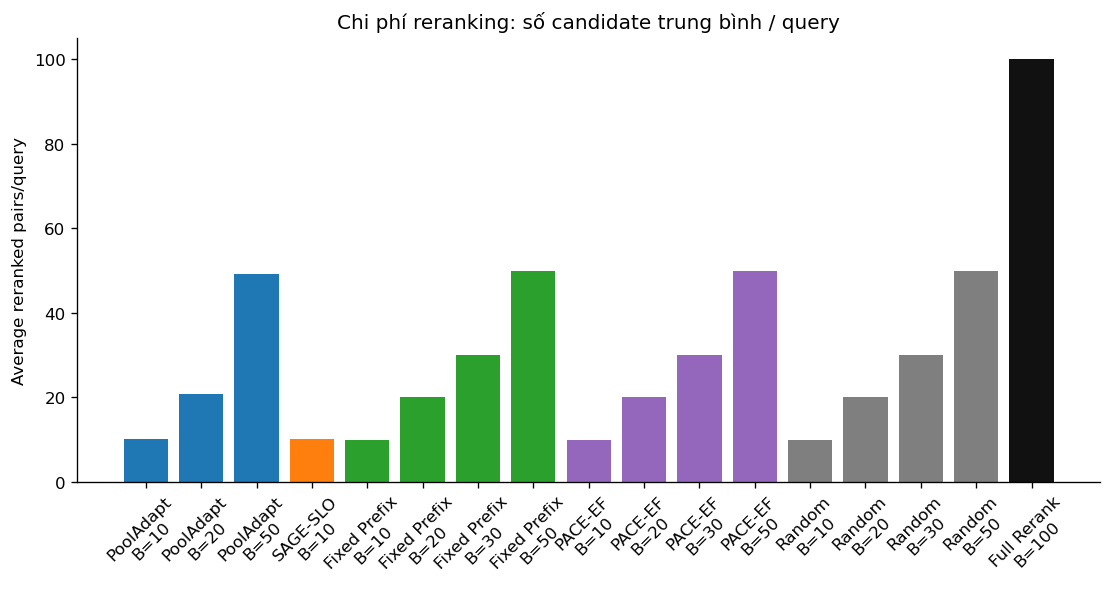

In [53]:
plot_bars("avg_reranked_pairs", "14_test_average_reranked_pairs.png", "Chi phí reranking: số candidate trung bình / query", "Average reranked pairs/query")


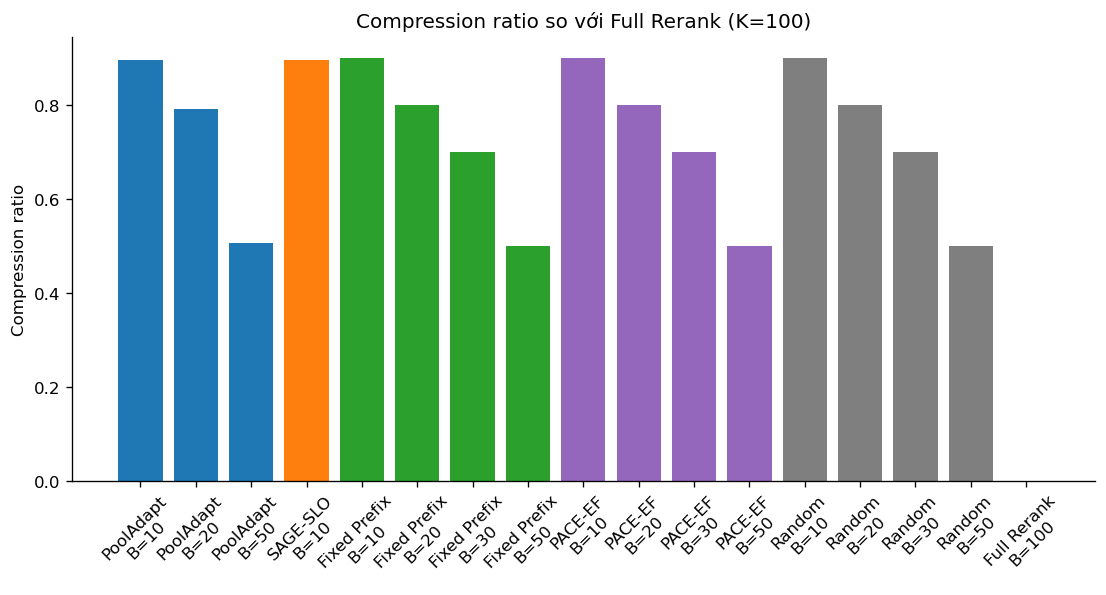

In [54]:
plot_bars("compression_ratio", "15_test_compression_ratio.png", "Compression ratio so với Full Rerank (K=100)", "Compression ratio")


## **7. Phân tích Reranking Latency**

### 7.1. Mean latency


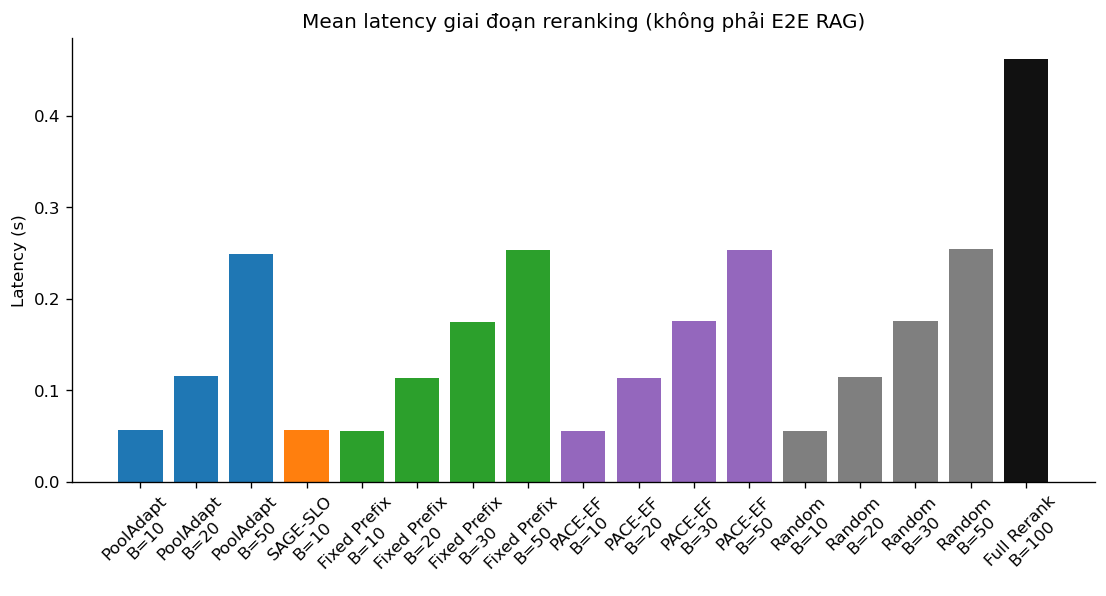

In [55]:
plot_bars("mean_reranking_latency", "16_test_mean_reranking_latency.png", "Mean latency giai đoạn reranking (không phải E2E RAG)", "Latency (s)")


### 7.2. P50 và P95 latency


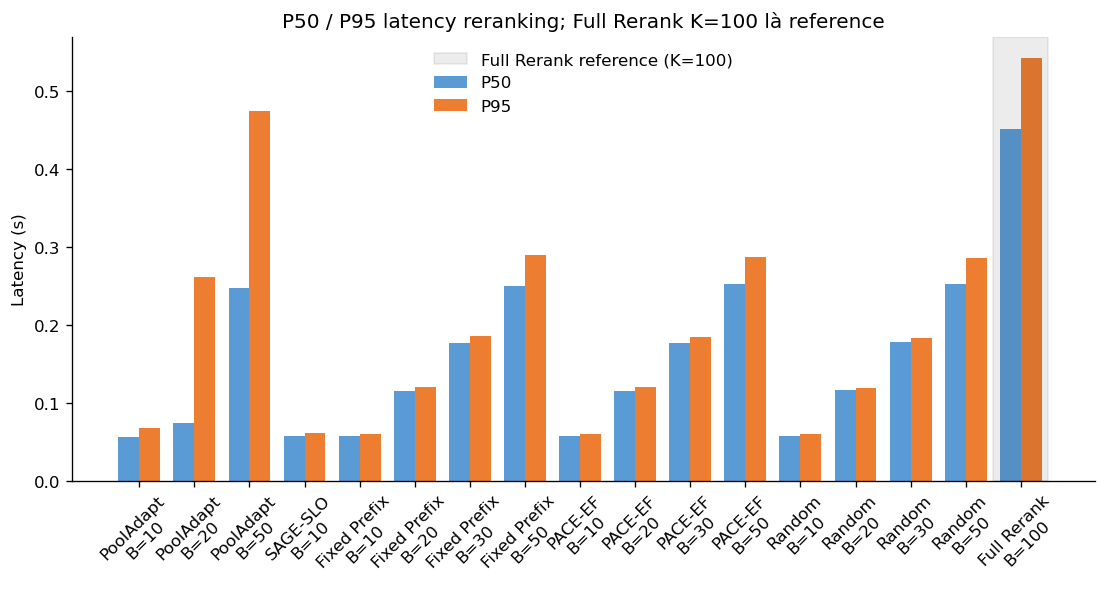

In [56]:
lat = pd.concat([matched[matched[mcol].isin(METHODS[:-1])], full], ignore_index=True)
if {"p50_reranking_latency", "p95_reranking_latency"} <= set(lat.columns) and not lat.empty:
    x = np.arange(len(lat)); labels = [f"{r[mcol]}\nB={int(r[tcol])}" for _, r in lat.iterrows()]
    fig, ax = plt.subplots(figsize=(11,4.8))
    ax.bar(x-.19, lat["p50_reranking_latency"], .38, label="P50", color="#5b9bd5")
    ax.bar(x+.19, lat["p95_reranking_latency"], .38, label="P95", color="#ed7d31")
    full_positions = np.flatnonzero(lat[mcol].eq("Full Rerank"))
    if len(full_positions):
        ax.axvspan(full_positions[0] - 0.5, full_positions[0] + 0.5, color=COLORS["Full Rerank"], alpha=0.08, label="Full Rerank reference (K=100)")
    ax.set(title="P50 / P95 latency reranking; Full Rerank K=100 là reference", ylabel="Latency (s)", xticks=x, xticklabels=labels)
    ax.tick_params(axis="x", rotation=45); ax.legend(frameon=False)
    save_and_show(fig, "17_test_latency_percentiles.png")
else: print("Skip Figure 17: thiếu P50/P95 latency.")


### 7.3. Latency reduction


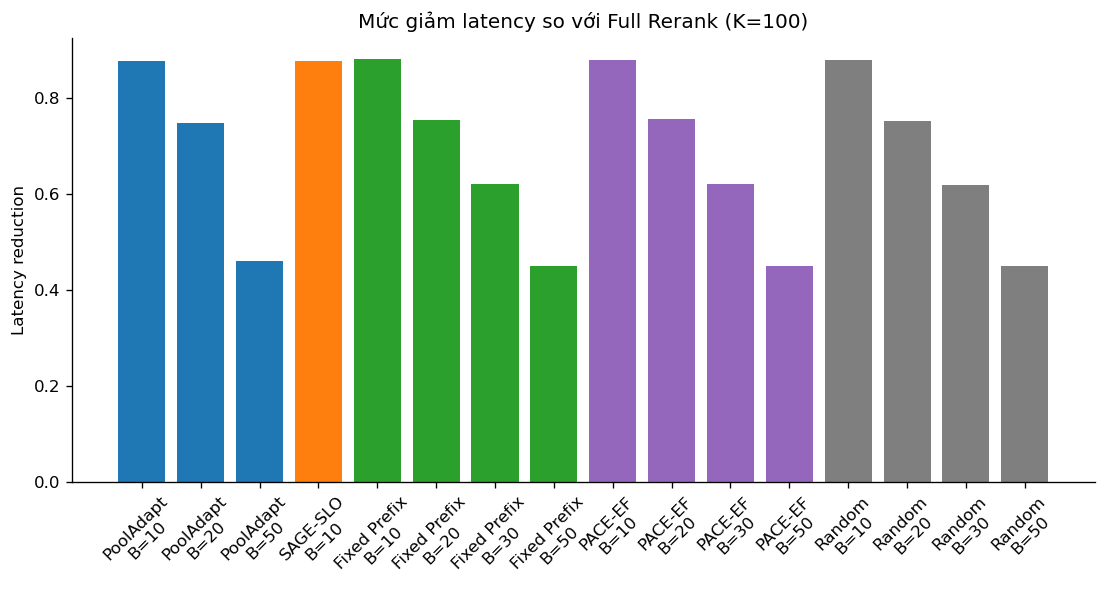

In [57]:
plot_bars("latency_reduction", "18_test_latency_reduction.png", "Mức giảm latency so với Full Rerank (K=100)", "Latency reduction", include_full=False)


## **8. Quality–Cost Trade-off**

Biểu đồ dùng actual average reranked pairs/query. Đây không phải Pareto frontier.


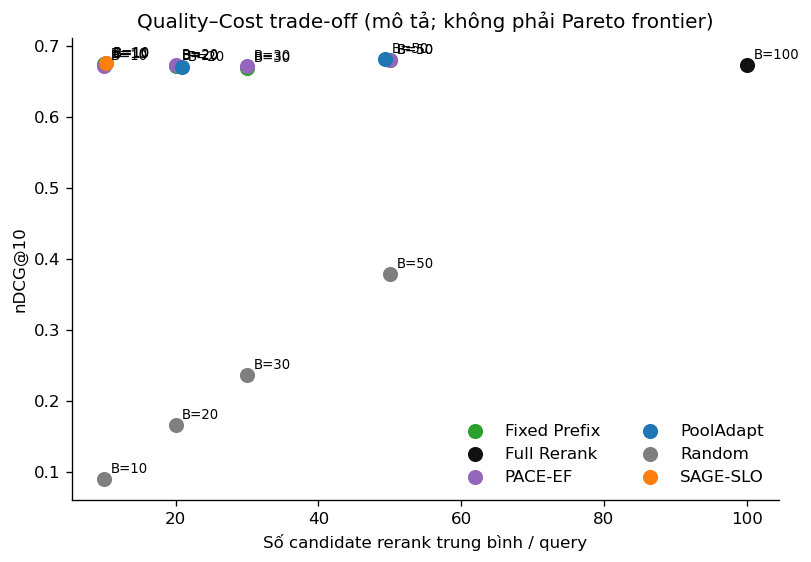

In [58]:
if actual_col and "nDCG@10" in comp.columns:
    trade = pd.concat([matched[matched[mcol].isin(METHODS[:-1])], full], ignore_index=True)
    fig, ax = plt.subplots(figsize=(7.6,5))
    for method, subset in trade.groupby(mcol):
        ax.scatter(subset[actual_col], subset["nDCG@10"], s=65, color=COLORS.get(method,"#333"), label=method)
        for _, row in subset.iterrows():
            ax.annotate(f"B={int(row[tcol])}", (row[actual_col], row["nDCG@10"]), xytext=(4,4), textcoords="offset points", fontsize=8)
    ax.set(title="Quality–Cost trade-off (mô tả; không phải Pareto frontier)", xlabel="Số candidate rerank trung bình / query", ylabel="nDCG@10")
    ax.legend(frameon=False, ncol=2); save_and_show(fig, "19_test_quality_cost_tradeoff.png")
else: print("Skip Figure 19: thiếu nDCG@10 hoặc actual budget.")


## **9. Phân tích Adaptive-K của PoolAdapt**

Mỗi target budget là một operating point được calibration riêng. Vì vậy mọi phân tích `selected_K`, `predicted_budget`, và `reranked_pairs` ở đây đều giữ nguyên `target_budget`; không gộp các operating point thành một phân bố Adaptive-K duy nhất. Chỉ dùng per-query K từ final artifact, không recompute quality metrics.


In [59]:
VALID_K = [10, 20, 30, 50, 100]
pool_q = pd.DataFrame()
adaptivity_audit = pd.DataFrame()
operating_k_counts = {}
near_fixed_budgets = []
if qm is not None:
    qmethod = resolve_column(qm, ["method"])
    qtarget = resolve_column(qm, ["target_budget", "budget"])
    kcol = resolve_column(qm, ["predicted_budget", "selected_K", "reranked_pairs"])
    if kcol == "reranked_pairs":
        print("Adaptive-K audit: using reranked_pairs as actual selected K.")
    if qmethod and qtarget and kcol:
        pool_q = qm[qm[qmethod].eq("PoolAdapt")].copy()
        pool_q["_target_budget"] = pd.to_numeric(pool_q[qtarget], errors="coerce")
        pool_q["_selected_k"] = pd.to_numeric(pool_q[kcol], errors="coerce")
        if pool_q[["_target_budget", "_selected_k"]].isna().any().any():
            raise ValueError("PoolAdapt có target budget hoặc selected K thiếu/không phải số.")
        invalid_k = sorted(set(pool_q["_selected_k"].astype(int)) - set(VALID_K))
        if invalid_k:
            raise ValueError(f"PoolAdapt có selected K không hợp lệ: {invalid_k}")
        audit_rows = []
        for budget in TARGETS:
            operating_point = pool_q[pool_q["_target_budget"].eq(budget)]
            if operating_point.empty:
                raise ValueError(f"Thiếu PoolAdapt operating point cho target budget B={budget}.")
            counts = operating_point["_selected_k"].astype(int).value_counts().reindex(VALID_K, fill_value=0)
            operating_k_counts[budget] = counts
            selected_k = operating_point["_selected_k"]
            pct_equal = selected_k.eq(budget).mean()
            pct_different = selected_k.ne(budget).mean()
            audit_rows.append({"target_budget": budget, "n_queries": len(operating_point), **{f"K={k}": int(counts.loc[k]) for k in VALID_K}, "pct_K_equal_target": pct_equal, "pct_K_different_target": pct_different, "min_K": selected_k.min(), "max_K": selected_k.max(), "mean_K": selected_k.mean()})
        adaptivity_audit = pd.DataFrame(audit_rows)
        near_fixed_budgets = adaptivity_audit.loc[adaptivity_audit["pct_K_different_target"].lt(0.05), "target_budget"].astype(int).tolist()
        display(adaptivity_audit.style.format({"pct_K_equal_target": "{:.1%}", "pct_K_different_target": "{:.1%}", "mean_K": "{:.2f}"}))
    else:
        print("Không có cột method, target budget, hoặc selected K/predicted budget hợp lệ cho PoolAdapt.")
else:
    print("Không có test_query_metrics.csv.")


Adaptive-K audit: using reranked_pairs as actual selected K.


,target_budget,n_queries,K=10,K=20,K=30,K=50,K=100,pct_K_equal_target,pct_K_different_target,min_K,max_K,mean_K
0,10,300,295,2,3,0,0,98.3%,1.7%,10,30,10.27
1,20,300,151,60,58,26,5,20.0%,80.0%,10,100,20.83
2,30,300,91,38,63,90,18,21.0%,79.0%,10,100,32.87
3,50,300,18,21,60,154,47,51.3%,48.7%,10,100,49.33


OSError: [Errno 22] Invalid argument: 'd:\\Seminar KHDL\\pooladapt\\results\\phase2\\visualizations\\20_test_pooladapt_adaptive_k.png'

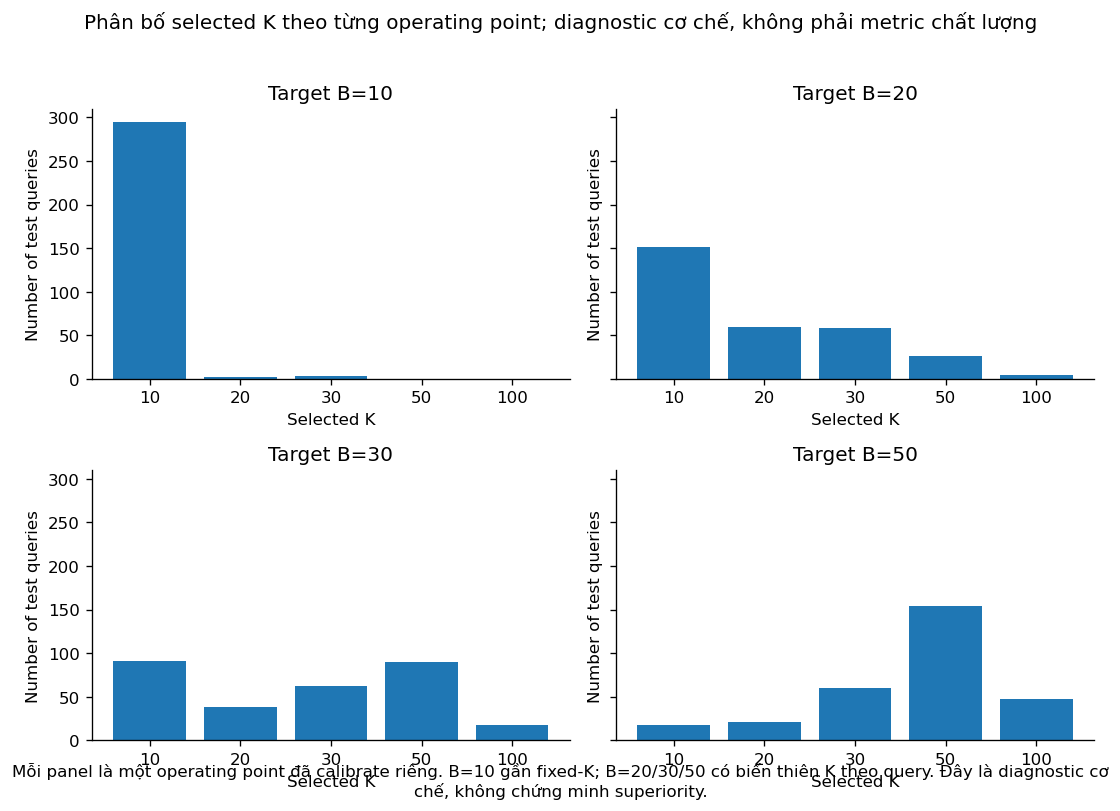

In [60]:
if not adaptivity_audit.empty:
    fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.5), sharey=True)
    for ax, budget in zip(axes.flat, TARGETS):
        counts = operating_k_counts[budget]
        ax.bar([str(k) for k in VALID_K], counts.reindex(VALID_K).values, color=COLORS["PoolAdapt"])
        ax.set(title=f"Target B={budget}", xlabel="Selected K", ylabel="Number of test queries")
    fig.suptitle("Phân bố selected K theo từng operating point; diagnostic cơ chế, không phải metric chất lượng", y=1.02)
    fig.text(0.5, 0.01, "Mỗi panel là một operating point đã calibrate riêng. B=10 gần fixed-K; B=20/30/50 có biến thiên K theo query. Đây là diagnostic cơ chế, không chứng minh superiority.", ha="center", va="bottom", wrap=True)
    fig.tight_layout()
    save_and_show(fig, "20_test_pooladapt_adaptive_k.png")

    interpretation = []
    for row in adaptivity_audit.itertuples(index=False):
        budget = int(row.target_budget)
        if row.pct_K_different_target < 0.05:
            interpretation.append(f"- B={budget}: PoolAdapt varies K for {row.pct_K_different_target:.1%} of queries. At this operating point, PoolAdapt is nearly degenerate to a fixed-K policy because fewer than 5% of queries receive a budget different from the target budget.")
        else:
            interpretation.append(f"- B={budget}: PoolAdapt varies K for {row.pct_K_different_target:.1%} of queries (range K={int(row.min_K)}–{int(row.max_K)}), indicating operating-point-specific query-dependent budget variation.")
    interpretation.append("This is a mechanism/adaptivity diagnostic, not a quality metric and not evidence of superiority. The candidate-pool-aware adaptive reranking-budget claim must therefore be qualified by the realized, operating-point-dependent degree of variation; a near-fixed operating point is a limitation/diagnostic finding rather than strong query-level adaptivity.")
    display(Markdown("### Figure 20 interpretation\n\n" + "\n".join(interpretation)))
else:
    print("Skip Figure 20: không có per-operating-point selected K hợp lệ.")


## **10. Phân tích Random Seed Variability**

Error bar là standard deviation giữa 5 random seeds, không phải độ lệch chuẩn giữa các TEST queries.


Random seed audit PASS (0–4) theo budget: {10: [0, 1, 2, 3, 4], 20: [0, 1, 2, 3, 4], 30: [0, 1, 2, 3, 4], 50: [0, 1, 2, 3, 4]}


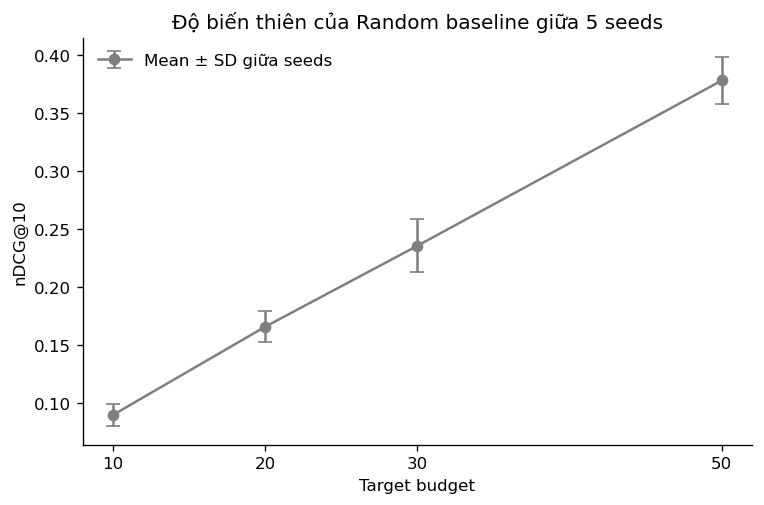

In [ ]:
if random_seed is not None and "nDCG@10" in random_seed.columns:
    rm, rt, rseed = resolve_column(random_seed,["method"]), resolve_column(random_seed,["target_budget","budget"]), resolve_column(random_seed,["seed"])
    rnd = random_seed[random_seed[rm].eq("Random")].copy()
    seed_summary = rnd.groupby(rt)["nDCG@10"].agg(["mean","std","count"]).reindex(TARGETS)
    expected_seeds = {0, 1, 2, 3, 4}
    seeds_by_budget = rnd.groupby(rt)[rseed].apply(lambda values: set(pd.to_numeric(values, errors="coerce").dropna().astype(int)))
    if not seeds_by_budget.map(lambda seeds: seeds == expected_seeds).all():
        raise ValueError(f"Random baseline không có đúng 5 seeds {{0,1,2,3,4}}: {seeds_by_budget.to_dict()}")
    print("Random seed audit PASS (0–4) theo budget:", {int(budget): sorted(seeds) for budget, seeds in seeds_by_budget.items()})
    valid = seed_summary.dropna()
    if not valid.empty:
        fig, ax = plt.subplots(figsize=(7.2,4.4))
        ax.errorbar(valid.index, valid["mean"], yerr=valid["std"], fmt="o-", capsize=4, color=COLORS["Random"], label="Mean ± SD giữa seeds")
        ax.set(title="Random baseline: mean nDCG@10 ± std qua 5 seeds (Phase 2)", xlabel="Target budget", ylabel="nDCG@10", xticks=TARGETS)
        ax.legend(frameon=False); save_and_show(fig, "21_test_random_seed_variability.png")
else: print("Skip Figure 21: thiếu random_seed_results.csv hoặc nDCG@10.")


## **11. Phân tích Statistical Results**

Chỉ dùng kết quả đã ghi trong `statistical_analysis.csv`. p > 0.05 được diễn giải là không phát hiện khác biệt có ý nghĩa thống kê; không phải equivalence.


,method_a,budget_a,method_b,budget_b,metric,p_Holm,interpretation,So sánh
18,PoolAdapt,10,Fixed Prefix,10,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs Fixed Prefix (B=10)
21,PoolAdapt,10,PACE-EF,10,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs PACE-EF (B=10)
24,PoolAdapt,10,Random,10,nDCG@10,2.720673e-42,statistically significant difference detected,PoolAdapt vs Random (B=10)
36,PoolAdapt,10,SAGE-SLO,10,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs SAGE-SLO (B=10)
54,PoolAdapt,20,Fixed Prefix,20,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs Fixed Prefix (B=20)
57,PoolAdapt,20,PACE-EF,20,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs PACE-EF (B=20)
60,PoolAdapt,20,Random,20,nDCG@10,6.159103e-41,statistically significant difference detected,PoolAdapt vs Random (B=20)
90,PoolAdapt,50,Fixed Prefix,50,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs Fixed Prefix (B=50)
93,PoolAdapt,50,PACE-EF,50,nDCG@10,1.000000e+00,no statistically significant difference detected,PoolAdapt vs PACE-EF (B=50)
96,PoolAdapt,50,Random,50,nDCG@10,2.688551e-37,statistically significant difference detected,PoolAdapt vs Random (B=50)


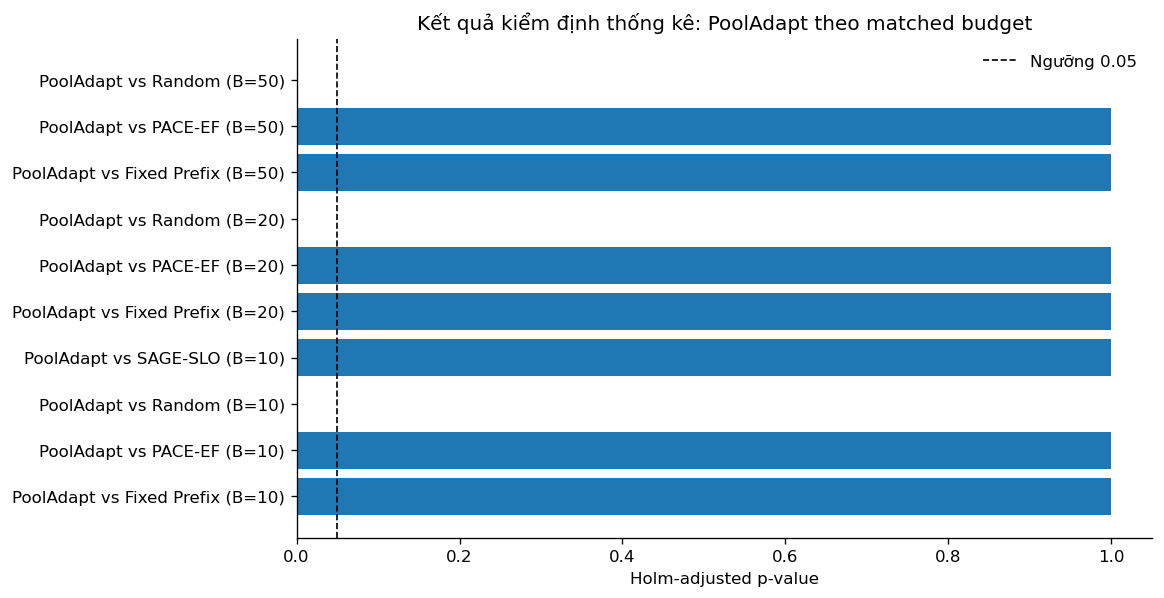

In [ ]:
if stats is not None:
    a = resolve_column(stats, ["method_a"])
    b = resolve_column(stats, ["method_b"])
    budget_a = resolve_column(stats, ["budget_a"])
    budget_b = resolve_column(stats, ["budget_b"])
    metric = resolve_column(stats, ["metric"])
    p = resolve_column(stats, ["p_Holm", "holm_p_value", "adjusted_p_value"])
    interpretation_col = resolve_column(stats, ["interpretation"])
    if all([a, b, budget_a, budget_b, metric, p]):
        comparators = ["Fixed Prefix", "PACE-EF", "SAGE-SLO", "Random"]
        selected = stats[(((stats[a].eq("PoolAdapt")) & stats[b].isin(comparators)) | ((stats[b].eq("PoolAdapt")) & stats[a].isin(comparators))) & stats[metric].eq("nDCG@10")].copy()
        if not selected.empty:
            pool_is_a = selected[a].eq("PoolAdapt")
            pool_budget = selected[budget_a].where(pool_is_a, selected[budget_b])
            other_method = selected[b].where(pool_is_a, selected[a])
            selected["So sánh"] = "PoolAdapt vs " + other_method.astype(str) + " (B=" + pool_budget.astype(int).astype(str) + ")"
            display_cols = [a, budget_a, b, budget_b, metric, p] + ([interpretation_col] if interpretation_col else [])
            display(selected[display_cols + ["So sánh"]])
            fig, ax = plt.subplots(figsize=(9.2, max(4.4, 0.42 * len(selected) + 1.2)))
            ax.barh(selected["So sánh"], selected[p], color=COLORS["PoolAdapt"])
            ax.axvline(.05, color="black", linestyle="--", linewidth=1, label="Ngưỡng 0.05")
            ax.set(title="Holm-adjusted p-value: PoolAdapt vs baseline (matched budget); p≥0.05 ≠ equivalence", xlabel="Holm-adjusted p-value")
            ax.legend(frameon=False)
            save_and_show(fig, "22_test_statistical_analysis.png")
        else:
            print("Không có kết quả statistical comparison tương ứng trong final artifacts.")
    else:
        print("Skip Figure 22: thiếu cột statistical cần thiết, gồm budget_a/budget_b.")
else:
    print("Skip Figure 22: không có statistical_analysis.csv.")


## **12. Tổng hợp kết quả**

Các nhận xét dưới đây được sinh từ artifacts đã tải; không tạo số liệu mới.


In [ ]:
failed = calibration_audit[~calibration_audit["Khớp ±5%"]] if not calibration_audit.empty else pd.DataFrame()
pool_matched = matched[matched[mcol].eq("PoolAdapt")].sort_values(tcol) if not matched.empty else pd.DataFrame()
if not adaptivity_audit.empty:
    adaptivity_summary = "; ".join(f"B={int(row.target_budget)}: {row.pct_K_different_target:.1%} K khác target (K={int(row.min_K)}–{int(row.max_K)})" for row in adaptivity_audit.itertuples(index=False))
    adaptivity_finding = "PoolAdapt exposes query-dependent K selection, but the degree of realized budget variation is operating-point dependent: " + adaptivity_summary + "."
    if near_fixed_budgets:
        adaptivity_finding += " Near-fixed behavior is observed at " + ", ".join(f"B={budget}" for budget in near_fixed_budgets) + "; this operating point is close to a fixed-K policy."
else:
    adaptivity_finding = "Không có dữ liệu selected K hợp lệ để kết luận về adaptive-K."
findings = [
    f"Final TEST dùng artifacts tại {ARTIFACT_DIR.name}; metadata ghi nhận {summary.get('test_query_count','không ghi nhận')} TEST queries và candidate pool N={summary.get('candidate_pool_size','không ghi nhận')}.",
    f"Có {len(matched)} dòng matched-budget theo comparative_results.matched_budget; {len(failed)} dòng calibration configuration không đạt tolerance (nếu file calibration có mặt) được báo cáo riêng.",
    ("PoolAdapt nDCG@10 tại matched budgets: " + ", ".join(f"B={int(row[tcol])}: {row['nDCG@10']:.4f}" for _, row in pool_matched.iterrows()) + ".") if not pool_matched.empty else "Không có dòng PoolAdapt matched-budget để mô tả nDCG@10.",
    "Full Rerank (K=100) được đọc động từ artifact làm quality/latency reference, không hard-code.",
    adaptivity_finding,
    "Adaptivity Audit là mechanism diagnostic, không phải quality metric và không tự nó chứng minh superiority.",
    "Kết luận thống kê chỉ dựa trên statistical_analysis.csv; không chạy test mới và p > 0.05 không đồng nghĩa equivalence.",
    "Giới hạn: SciFact, N=100, budget grid {10,20,30,50,100}, adapted baselines, locked protocol; heuristic branch không được đánh giá vì G2 FAIL."
]
display(Markdown("## 12. Tổng hợp kết quả\n" + "\n".join(f"{i+1}. {text}" for i, text in enumerate(findings))))
display(Markdown('''## 13. Kết luận và Limitations

Kết quả chỉ được diễn giải dưới locked SciFact evaluation protocol. PoolAdapt không chọn arbitrary candidate subset và không phải candidate-level relevance classifier: phương pháp chọn query-specific K rồi rerank các candidate đầu theo thứ tự RRF. PoolAdapt exposes query-dependent K selection, but the realized budget variation is operating-point dependent; in particular, any operating point flagged by the Adaptivity Audit as near-fixed must be interpreted as close to a fixed-K policy. Các sai lệch calibration và các comparison thống kê không có trong artifact được giữ nguyên trạng, không được thay thế bằng suy diễn mới.'''))


## 12. Tổng hợp kết quả
1. Final TEST dùng artifacts tại final_gpu; metadata ghi nhận 300 TEST queries và candidate pool N=100.
2. Có 17 dòng matched-budget theo comparative_results.matched_budget; 0 dòng calibration configuration không đạt tolerance (nếu file calibration có mặt) được báo cáo riêng.
3. PoolAdapt nDCG@10 tại matched budgets: B=10: 0.6748, B=20: 0.6704, B=50: 0.6816.
4. Full Rerank (K=100) được đọc động từ artifact làm quality/latency reference, không hard-code.
5. PoolAdapt exposes query-dependent K selection, but the degree of realized budget variation is operating-point dependent: B=10: 1.7% K khác target (K=10–30); B=20: 80.0% K khác target (K=10–100); B=30: 79.0% K khác target (K=10–100); B=50: 48.7% K khác target (K=10–100). Near-fixed behavior is observed at B=10; this operating point is close to a fixed-K policy.
6. Adaptivity Audit là mechanism diagnostic, không phải quality metric và không tự nó chứng minh superiority.
7. Kết luận thống kê chỉ dựa trên statistical_analysis.csv; không chạy test mới và p > 0.05 không đồng nghĩa equivalence.
8. Giới hạn: SciFact, N=100, budget grid {10,20,30,50,100}, adapted baselines, locked protocol; heuristic branch không được đánh giá vì G2 FAIL.

## 13. Kết luận và Limitations

Kết quả chỉ được diễn giải dưới locked SciFact evaluation protocol. PoolAdapt không chọn arbitrary candidate subset và không phải candidate-level relevance classifier: phương pháp chọn query-specific K rồi rerank các candidate đầu theo thứ tự RRF. PoolAdapt exposes query-dependent K selection, but the realized budget variation is operating-point dependent; in particular, any operating point flagged by the Adaptivity Audit as near-fixed must be interpreted as close to a fixed-K policy. Các sai lệch calibration và các comparison thống kê không có trong artifact được giữ nguyên trạng, không được thay thế bằng suy diễn mới.